In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


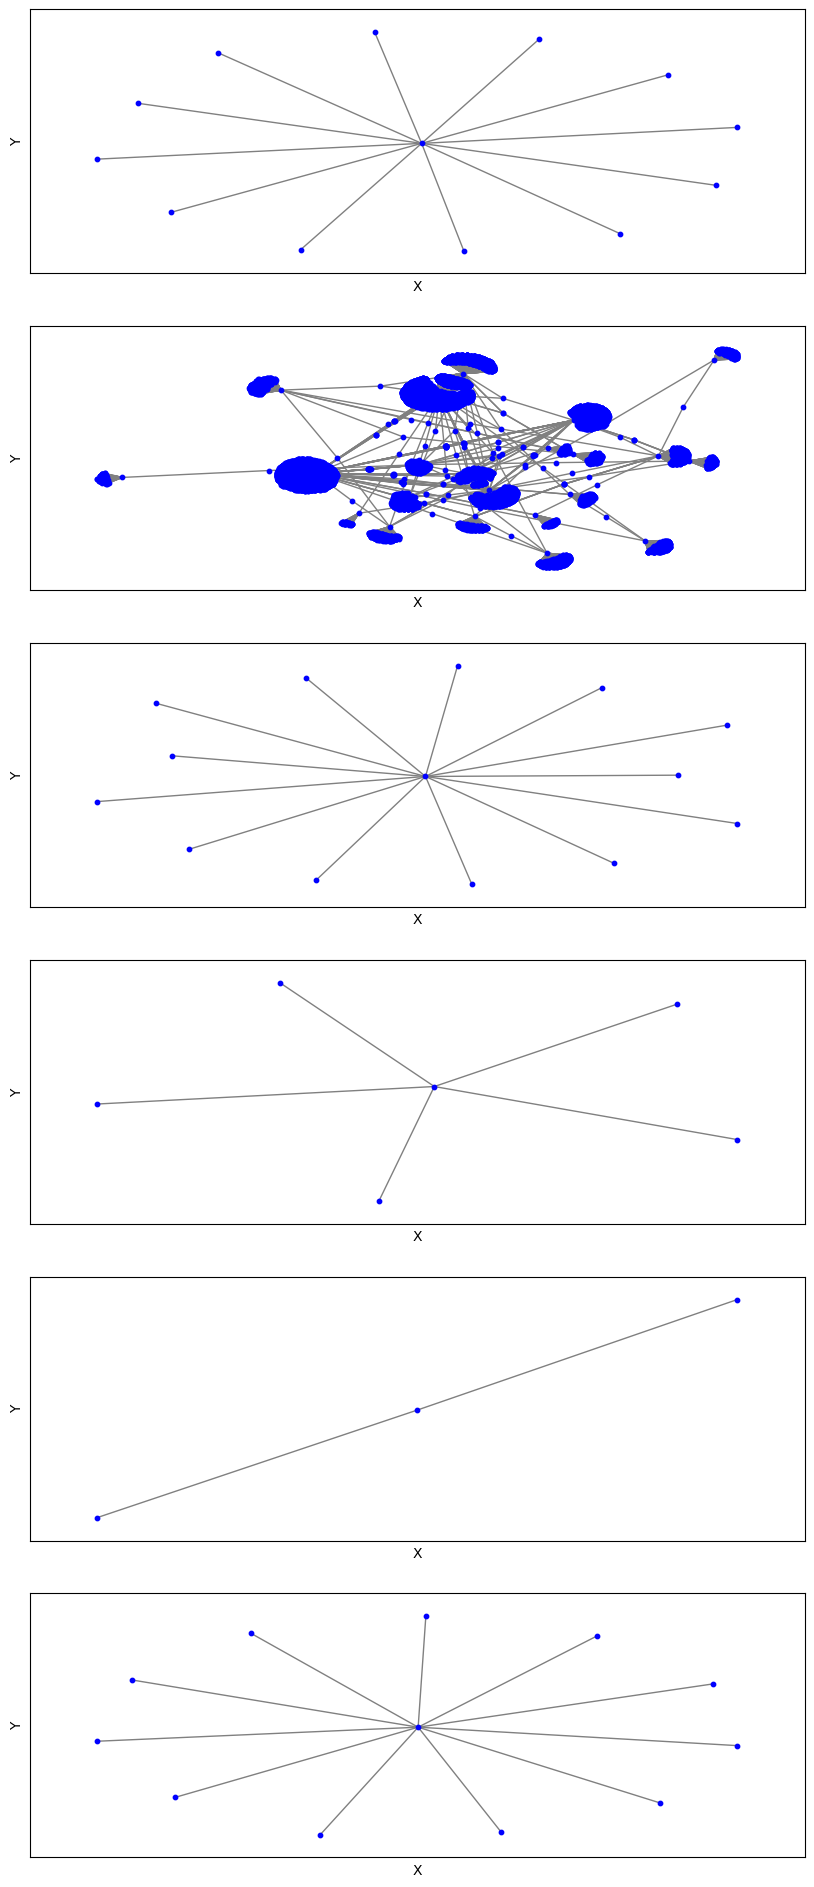

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
from openpyxl import load_workbook
from networkx.exception import NetworkXNoPath

# Load the workbook and select the active sheet
wb = load_workbook('/content/drive/MyDrive/graph/data_26_thousand.xlsx')
ws = wb.active

# Extract nodes from the Excel file
nodes = []
G = nx.Graph()

for row in range(2, 500):
    author = ws[f'B{row}'].value
    if author is not None:
        node1 = author
        node2 = ws[f'H{row}'].value
        if node2 is not None:
            names = [name.strip("'") for name in node2.split(", ")]
            for i in names:
                if i is not None and node1 is not None:
                    found = False
                    G.add_node(node1)

                    for n in nodes:
                        if n[1] == node1:
                            G.add_node(i)
                            G.add_edge(n[1], i)
                            found = True
                    if not found:
                        nodes.append((node1, i))
                        G.add_edge(node1, i)
                        
                        G.add_node(i)

# Get the connected components
components = list(nx.connected_components(G))
# z = [('Douglas G Altman', 'B. Gersh')]

# Plot each component
if len(components) == 1:
    fig, ax = plt.subplots()
    subgraph = G.subgraph(components[0])
    pos = nx.spring_layout(subgraph)

    # Draw nodes
    nx.draw_networkx_nodes(subgraph, pos, ax=ax, node_color='blue', node_size=100, label=True)

    # Draw edges
    nx.draw_networkx_edges(subgraph, pos, ax=ax, edge_color='grey', width=1)

    # Set axis labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    # Perform analysis between nodes
    # for node_pair in z:
    #     node1, node2 = node_pair
    #     try:
    #         undirected_subgraph = subgraph.to_undirected()
    #         dijkstra_path = nx.dijkstra_path(undirected_subgraph, source=node1, target=node2)
    #         print(f"Dijkstra's Algorithm between {node1} and {node2}:")
    #         print(dijkstra_path)
    #     except NetworkXNoPath:
    #         print(f"No path between {node1} and {node2}")

else:
    fig, axes = plt.subplots(len(components), 1, figsize=(10, 4 * len(components)))

    # Plot each component
    for i, component in enumerate(components):
        ax = axes[i]
        subgraph = G.subgraph(component)
        pos = nx.spring_layout(subgraph)

        # Draw nodes
        nx.draw_networkx_nodes(subgraph, pos, ax=ax, node_color='blue', node_size=10, label=True)

        # Draw edges
        nx.draw_networkx_edges(subgraph, pos, ax=ax, edge_color='grey', width=1)

        # Set axis labels
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        # Perform analysis between nodes
        # for node_pair in z:
        #     node1, node2 = node_pair
        #     if any(node[0] == node1 for node in nodes):
        #         if any(node[1] == node2 for node in nodes):
        #             try:
        #                 undirected_subgraph = subgraph.to_undirected()
        #                 dijkstra_path = nx.dijkstra_path(undirected_subgraph, source=node1, target=node2)
        #                 print(f"Dijkstra's Algorithm between {node1} and {node2}:")
        #                 print(dijkstra_path)
        #             except NetworkXNoPath:
        #                 print(f"No path between {node1} and {node2}")
        #         else:
        #             print(f"Node {node2} doesn't exist")
        #     else:
        #         print(f"Node {node1} doesn't exist")

plt.show()


In [10]:
nx.edge_betweenness_centrality(G)


{('Douglas G Altman', 'G. Wheeler'): 4.700520993995672e-07,
 ('Douglas G Altman', 'A. Mander'): 4.700520993995672e-07,
 ('Douglas G Altman', 'A. Bedding'): 4.700520993995672e-07,
 ('Douglas G Altman', 'K. Brock'): 4.700520993995672e-07,
 ('Douglas G Altman', 'V. Cornelius'): 4.700520993995672e-07,
 ('Douglas G Altman', 'A. Grieve'): 4.700520993995672e-07,
 ('Douglas G Altman', 'T. Jaki'): 4.700520993995672e-07,
 ('Douglas G Altman', 'Sharon B. Love'): 4.700520993995672e-07,
 ('Douglas G Altman', 'Lang’o Odondi'): 4.700520993995672e-07,
 ('Douglas G Altman', 'C. Weir'): 4.700520993995672e-07,
 ('Douglas G Altman', 'C. Yap'): 4.700520993995672e-07,
 ('Douglas G Altman', 'S. Bond'): 4.700520993995672e-07,
 ('daniela bortoletto', 'P. Żyła'): 0.0002779966457865638,
 ('daniela bortoletto', 'P. Richardson'): 0.0002779966457865638,
 ('daniela bortoletto', 'O. Zenin'): 0.0002779966457865638,
 ('daniela bortoletto', 'A. Bettini'): 0.0002779966457865638,
 ('daniela bortoletto', 'L. Garren'): 0.00

In [11]:
nx.density(G)
# density(G) = (2 * num_edges) / (n * (n - 1))


0.0003068265078830675

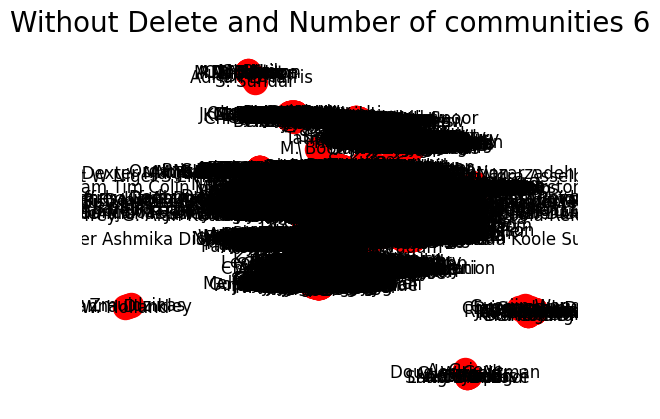

[('Douglas G Altman', 12), ('G. Wheeler', 1), ('A. Mander', 1), ('A. Bedding', 1), ('K. Brock', 1), ('V. Cornelius', 1), ('A. Grieve', 1), ('T. Jaki', 1), ('Sharon B. Love', 1), ('Lang’o Odondi', 1), ('C. Weir', 1), ('C. Yap', 1), ('S. Bond', 1), ('daniela bortoletto', 1706), ('P. Żyła', 1), ('P. Richardson', 1), ('O. Zenin', 1), ('A. Bettini', 1), ('L. Garren', 1), ('Vorobyev', 1), ('D. Groom', 1), ('M. Kenzie', 1), ('G. Zanderighi', 1), ('M. Karliner', 1), ('D. Chakraborty', 2), ('D. Asner', 2), ('V. Khoze', 2), ('T. Sjöstrand', 1), ('J. Beringer', 2), ('A. Godizov', 1), ('S. Bethke', 2), ('V. Petrov', 1), ('L. Verde', 1), ('G. Gerbier', 1), ('B. Allanach', 1), ('R. Kowalewski', 1), ('P. Nason', 1), ('S. Stone', 1), ('Y. Sakai', 1), ('J. Holder', 1), ('O. Schneider', 1), ('E. Pianori', 1), ('M. Silari', 1), ('K. Olive', 1), ('A. Cerri', 2), ('H. Gerber', 1), ('A. Gouvea', 1), ('R. Workman', 1), ('R. Ryutin', 1), ('K. Rabbertz', 1), ('V. S. Lugovsky', 1), ('T. Mannel', 1), ('F. Moortg

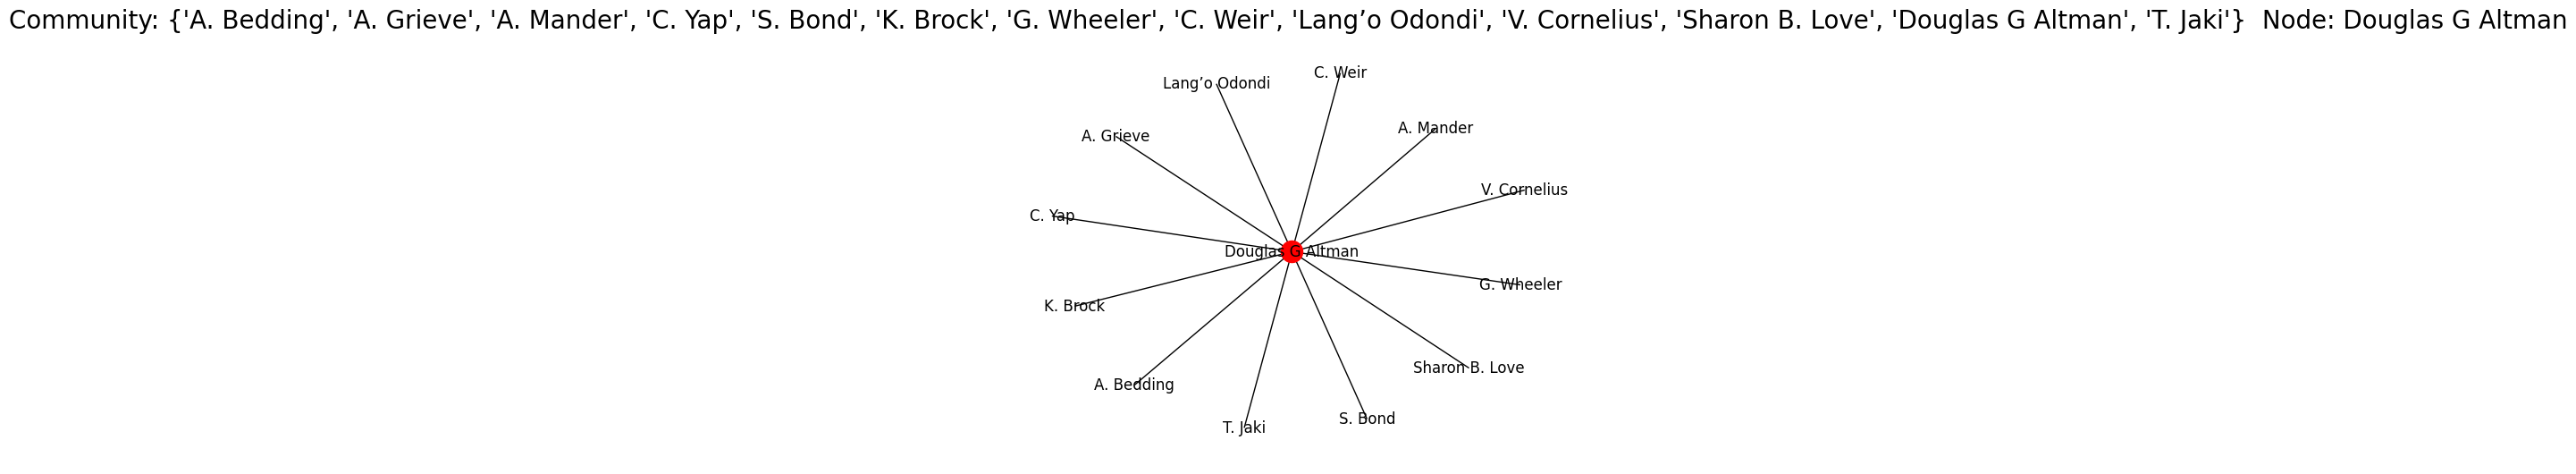

Community: {'R. Perchonok', 'D. Silva', 'P. Schaffner', 'A. Spathis', 'W. Hsueh', 'D. Boumediene', 'W. Breaden Madden', 'G. Keir', 'E. Copland', 'M. Alstaty', 'N. Shibata', 'J. Kostis', 'C. Christensen', 'N. van Remortel', 'G. Thorleifsson', 'L. Garrido', 'S. Taler', 'Morris J. Brown', 'R. Stafford', 'I. Richardson', 'M. K. Ayoub', 'G. Grammatopoulos', 'W. Sheu', 'A. De Min', 'H. Mungall', 'H. Sanders', 'L. Beilin', 'P. Läderach', 'W. Carithers', 'A. Vayaki', 'C. Herteliu', 'R. Logan', 'E. Widén', 'J. Lloyd-Smith', 'P. Gheeraert', 'U. Meissner', 'C. Ciocca', 'D. Zavrtanik', 'J. Parry', 'M. Ataç', 'Hye-Mi Jang', 'I. Paik', 'I. Caprini', 'John M. Wilson', 'S. Treweek', 'V. Guarino', 'S. Lewington', 'E. Vinyoles', 'E. Caoili', 'H. Hakonarson', 'Ben Ma', 'E. Erkut', 'N. Craddock', 'B. Bloch-Devaux', 'Shan Gao', 'M. Davier', 'M. Moch', 'M. Bau', 'C. Park', 'The Cms Collaboration', 'Qingshang Shi', 'C. Harris', 'W. Kostis', 'S. Vermeulen', 'Yongsung Kim', 'Donald P. Warsing', 'S. Palanque', 

ValueError: ignored

<Figure size 640x480 with 1 Axes>

Community: {'P. Dickinson', 'Adrian L Harris', 'O. A. Khan', 'M. Patil', 'A. Blann', 'A. Protheroe', 'D. Peel', 'S. Sundar', 'M. Middleton', 'M. Payne', 'M. Taylor', 'A. Harris', 'D. Talbot', 'C. Han'}
Node with highest degree: Adrian L Harris
Degree: 13


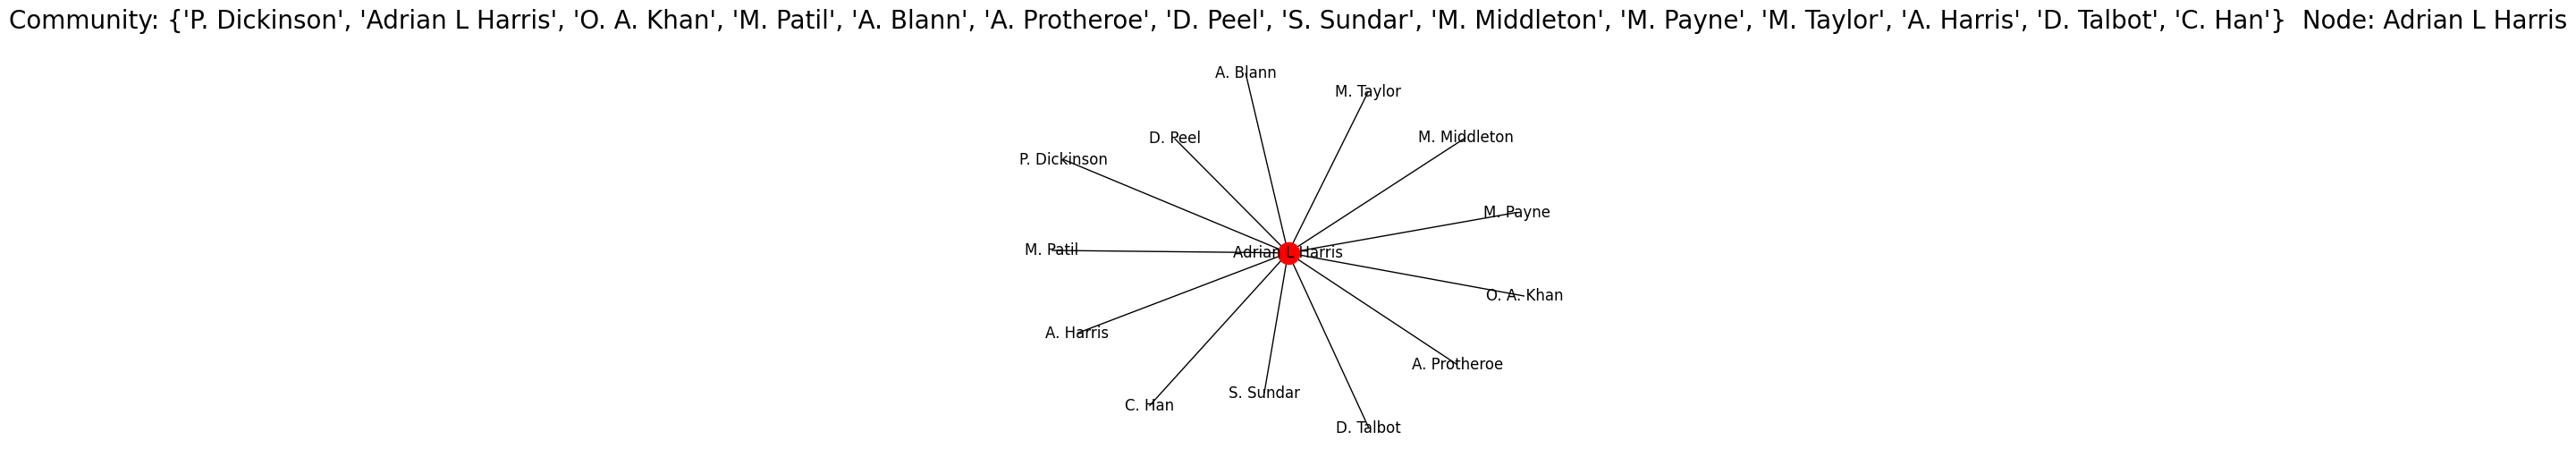

Community: {'Fleming Dm', 'C. Court', 'D. Crombie', 'Richard Hobbs', 'D. Fleming', 'Crombie Dl'}
Node with highest degree: Richard Hobbs
Degree: 5


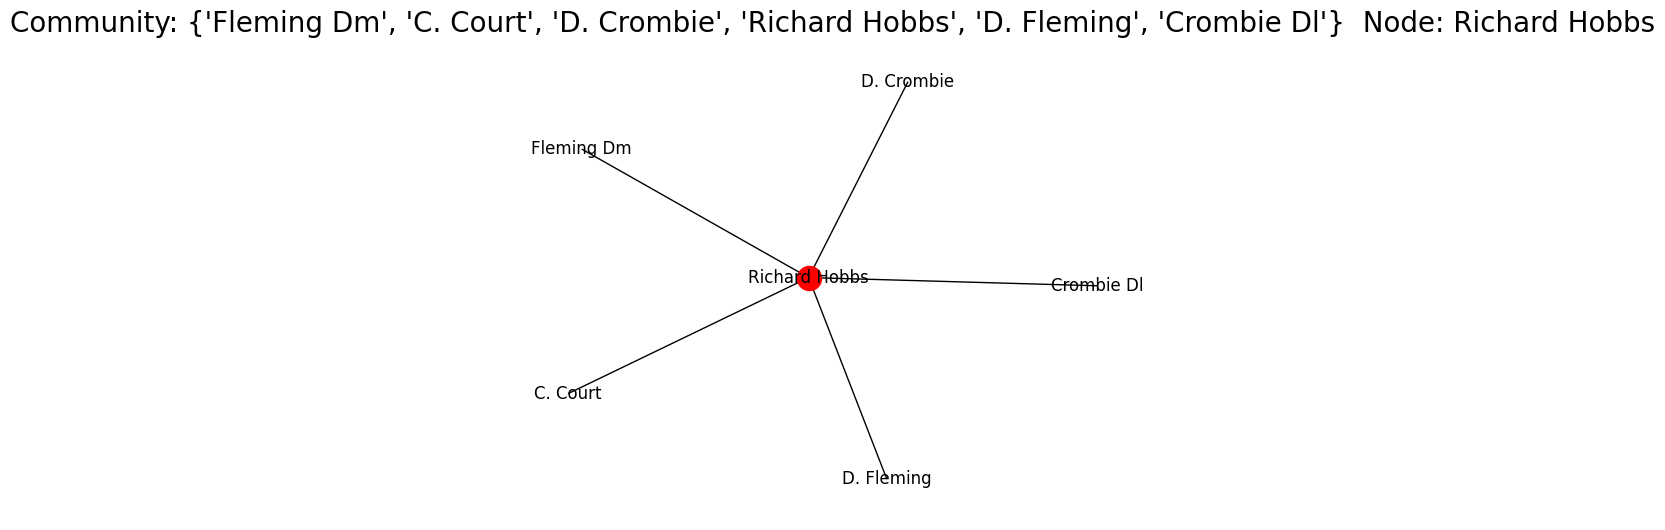

Community: {'W. Holland', 'J. Zmuidzinas', 'Joanna Dunkley'}
Node with highest degree: Joanna Dunkley
Degree: 2


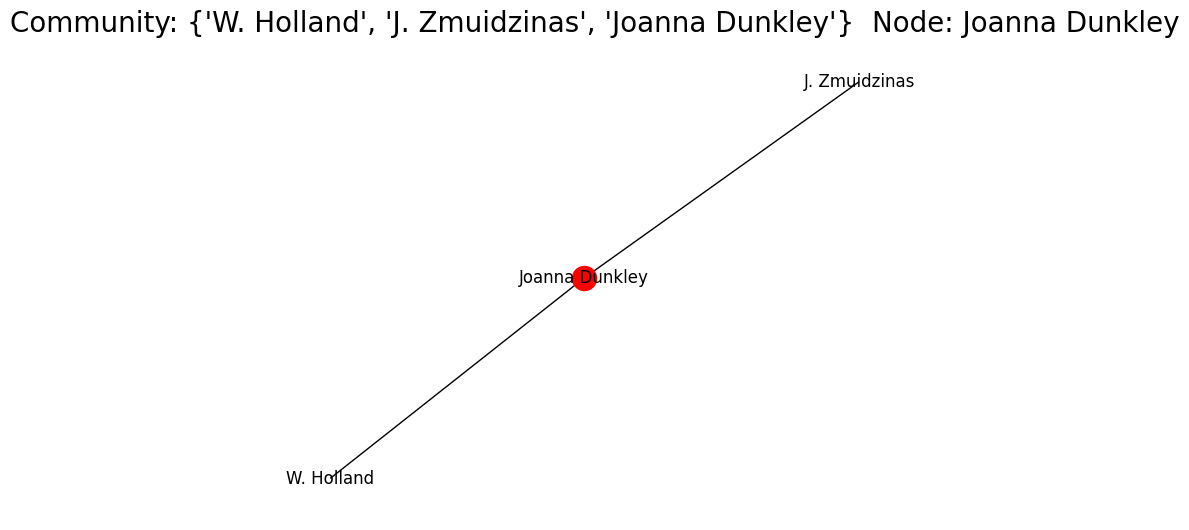

Community: {'T. Sederberg', 'N. M. White', 'A. Tourlidakis', 'M. Casey', 'A. O. Salas', 'G. Reich', 'R. Elder', 'M. Blair', 'Christopher Dye', 'J. C. Townsend', 'Takafumi Saito', 'Guo-jin Wang'}
Node with highest degree: Christopher Dye
Degree: 11


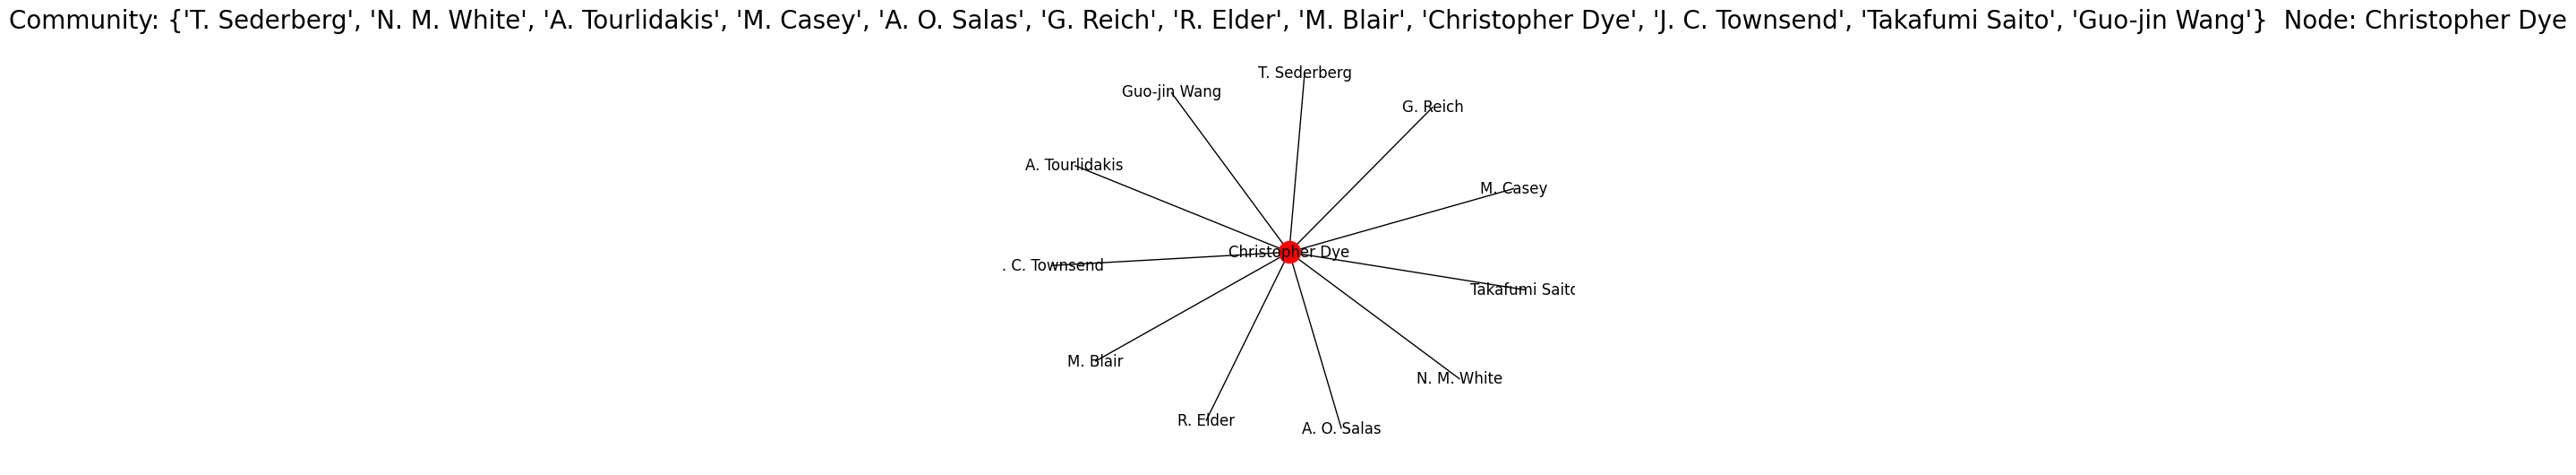

In [12]:



plt.title('Without Delete and Number of communities %s'%(nx.number_connected_components(G)), fontsize=20)

nx.draw(G, with_labels=True, node_color='r')
plt.show()
degrees = [(node,val) for (node, val) in G.degree()]
sorted(degrees, key=lambda x: x[1], reverse=True)
print(degrees)
communities = nx.connected_components(G)

# Iterate over each community
for community in communities:
    # Create a subgraph for the current community
    subgraph = G.subgraph(community)
    
    # Calculate the degrees of nodes in the subgraph
    degrees = subgraph.degree()
    
    # Find the node with the highest degree
    max_degree_node = max(degrees, key=lambda x: x[1])
    
    # Print the node with the highest degree in the current community
    print("Community:", community)
    print("Node with highest degree:", max_degree_node[0])
    print("Degree:", max_degree_node[1])

    # Plot the subgraph with the node highlighted
    nx.draw(subgraph, with_labels=True, node_color='r', nodelist=[max_degree_node[0]])
    plt.title('Community: {}  Node: {}'.format(community, max_degree_node[0]), fontsize=20)
    plt.show()





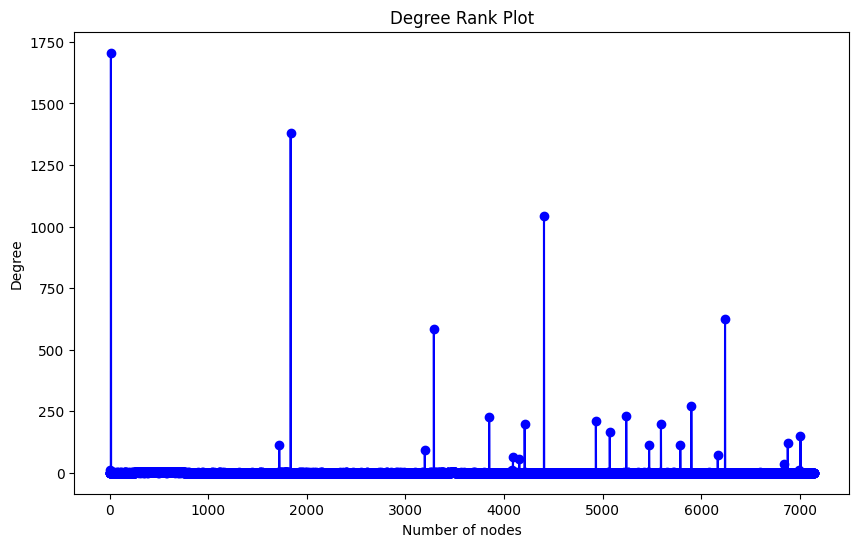

In [19]:
degree_sequence = [d for n, d in G.degree()]
dmax = max(degree_sequence)

# Create the figure and subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Degree sequence plot
ax.plot(degree_sequence, 'b-', marker='o')
ax.set_title('Degree Rank Plot')
ax.set_xlabel('Number of nodes')
ax.set_ylabel('Degree')

# Display the plot
plt.show()

In [14]:
degree_dict = dict(G.degree())
max_degree = max(degree_dict.values())
highest_degree_nodes = [node for node, degree in degree_dict.items() if degree == max_degree]
for node in highest_degree_nodes:

  print("Nodes with the highest degree:", highest_degree_nodes,degree_dict[node])

Nodes with the highest degree: ['daniela bortoletto'] 1706


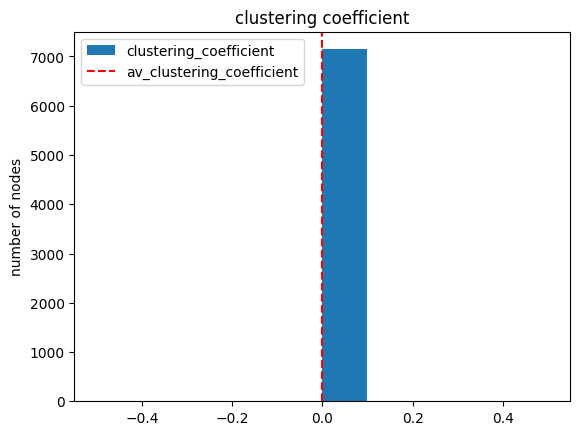

In [15]:
clustering_coefficient = nx.algorithms.cluster.clustering(G)
av_clustering_coefficient = sum(clustering_coefficient.values())/len(clustering_coefficient)
plt.hist(clustering_coefficient.values(), label ='clustering_coefficient')
plt.axvline(av_clustering_coefficient, color ='r', linestyle = 'dashed', label= 'av_clustering_coefficient')
plt.legend()
plt.ylabel('number of nodes')
plt.title('clustering coefficient')
plt.show()

dict_items([('Douglas G Altman', 0), ('G. Wheeler', 0), ('A. Mander', 0), ('A. Bedding', 0), ('K. Brock', 0), ('V. Cornelius', 0), ('A. Grieve', 0), ('T. Jaki', 0), ('Sharon B. Love', 0), ('Lang’o Odondi', 0), ('C. Weir', 0), ('C. Yap', 0), ('S. Bond', 0), ('daniela bortoletto', 2), ('P. Żyła', 2), ('P. Richardson', 2), ('O. Zenin', 2), ('A. Bettini', 2), ('L. Garren', 2), ('Vorobyev', 2), ('D. Groom', 2), ('M. Kenzie', 2), ('G. Zanderighi', 2), ('M. Karliner', 2), ('D. Chakraborty', 2), ('D. Asner', 2), ('V. Khoze', 2), ('T. Sjöstrand', 2), ('J. Beringer', 2), ('A. Godizov', 2), ('S. Bethke', 2), ('V. Petrov', 2), ('L. Verde', 2), ('G. Gerbier', 2), ('B. Allanach', 2), ('R. Kowalewski', 2), ('P. Nason', 2), ('S. Stone', 2), ('Y. Sakai', 2), ('J. Holder', 2), ('O. Schneider', 2), ('E. Pianori', 2), ('M. Silari', 2), ('K. Olive', 2), ('A. Cerri', 2), ('H. Gerber', 2), ('A. Gouvea', 2), ('R. Workman', 2), ('R. Ryutin', 2), ('K. Rabbertz', 2), ('V. S. Lugovsky', 2), ('T. Mannel', 2), ('F.

<ipython-input-16-50f6e07615ed>:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


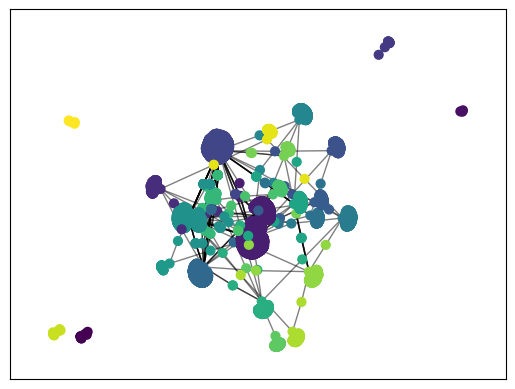

In [16]:
import community.community_louvain as community
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# load the karate club graph

#first compute the best partition
partition = community.best_partition(G)
print(partition.items())
# draw the graph
pos = nx.spring_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=40,
                       cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

In [ ]:
NUM_ITERATIONS = 10
edge_effective=[]
for i in range(NUM_ITERATIONS):
    edge_betweenness = nx.edge_betweenness_centrality(G).items()
    edge_to_delete = sorted(edge_betweenness, key=lambda pair: -pair[1])[0][0]
    edge_effective.append(edge_to_delete)
print(edge_effective)

In [ ]:
z = [('Douglas G Altman', 'B. Gersh')]

for node_pair in z:
            node1, node2 = node_pair
            if any(node[0] == node1 for node in nodes):
                if any(node[1] == node2 for node in nodes):
                    try:
                        undirected_subgraph = subgraph.to_undirected()
                        dijkstra_path = nx.dijkstra_path(undirected_subgraph, source=node1, target=node2)
                        print(f"Dijkstra's Algorithm between {node1} and {node2}:")
                        print(dijkstra_path)
                    except NetworkXNoPath:
                        print(f"No path between {node1} and {node2}")
                else:
                    print(f"Node {node2} doesn't exist")
            else:
                print(f"Node {node1} doesn't exist")